## グラフの作成

In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

In [2]:
def space_clean(row):
    row = row.replace(". ", "").replace(" .", "").replace("  ", " ")
    return row

def canonicalize(smiles):
    try:
        new_smiles = Chem.MolToSmiles(Chem.MolFromSmiles(smiles), canonical=True)
    except:
        new_smiles = None
    return new_smiles

In [3]:
df = pd.read_csv("../data/Buchwald-Hartwig/Dreher_and_Doyle_reaction_t5_ready.csv")

In [4]:
# 必須カラムの存在チェックと補完
required_cols = ["REACTANT", "CATALYST", "REAGENT", "SOLVENT", "PRODUCT"]
for col in required_cols:
    if col not in df.columns:
        df[col] = ""

# YIELDを標準化（0-1に正規化）
if "YIELD" in df.columns:
    df["YIELD"] = df["YIELD"].clip(0, 100) / 100

In [5]:
df["REAGENT"] = df["CATALYST"].fillna(" ") + "." + df["REAGENT"].fillna(" ") + "." + df["SOLVENT"].fillna(" ")

In [6]:
for col in ["REAGENT", "REACTANT", "PRODUCT"]:
    df[col] = df[col].apply(space_clean)
    df[col] = df[col].apply(lambda x: canonicalize(x) if x != " " else " ")
    df = df[~df[col].isna()].reset_index(drop=True)
    df[col] = df[col].apply(lambda x: ".".join(sorted(x.split("."))))

In [7]:
import torch
from torch_geometric.data import Data

import os
import shutil
from tqdm import tqdm
import numpy as np

/root/ReactionT5-bo-yield/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
def get_global_symbols(df, smiles_cols):
    symbols = set()
    for col in smiles_cols:
        if col in df.columns:
            for sm in df[col].dropna():
                mol = Chem.MolFromSmiles(sm)
                if mol:
                    for atom in mol.GetAtoms():
                        symbols.add(atom.GetSymbol())
    return sorted(list(symbols))

def get_atom_features(atom, symbol_list):
    # 出現したシンボルのリストに基づいてOne-hot化
    symbol = [1 if atom.GetSymbol() == s else 0 for s in symbol_list]
    
    features = symbol + [
        atom.GetDegree(),
        atom.GetTotalValence(),
        atom.GetIsAromatic() * 1.0,
    ]
    return torch.tensor(features, dtype=torch.float)

def get_bond_features(bond):
    # 結合種別のOne-hot (4次元)
    bt = bond.GetBondType()
    features = [
        bt == Chem.rdchem.BondType.SINGLE,
        bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE,
        bt == Chem.rdchem.BondType.AROMATIC,
    ]
    return torch.tensor(features, dtype=torch.float)

def smiles_to_pyg_graph(smiles_list, symbol_list, yield_val=None):
    all_atom_feats = []
    all_edge_indices = []
    all_edge_feats = []
    current_node_offset = 0
    
    for sm in smiles_list:
        mol = Chem.MolFromSmiles(sm)
        if mol is None: continue
        mol = Chem.AddHs(mol)
        
        # 1. 原子特徴量の取得
        for atom in mol.GetAtoms():
            all_atom_feats.append(get_atom_features(atom, symbol_list))
            
        # 2. 結合特徴量の取得
        for bond in mol.GetBonds():
            start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            # 無向グラフとして扱うため両方向のエッジを追加
            all_edge_indices.append([start + current_node_offset, end + current_node_offset])
            all_edge_indices.append([end + current_node_offset, start + current_node_offset])
            
            # 結合そのものの特徴量
            b_feat = get_bond_features(bond)
            all_edge_feats.append(b_feat)
            all_edge_feats.append(b_feat)
            
        current_node_offset += mol.GetNumAtoms()
    
    # 全分子が空だった場合のガード
    if not all_atom_feats:
        return None

    return Data(
        x=torch.stack(all_atom_feats),
        edge_index=torch.tensor(all_edge_indices, dtype=torch.long).t().contiguous(),
        edge_attr=torch.stack(all_edge_feats),
        y=torch.tensor([yield_val], dtype=torch.float) if yield_val is not None else None
    )

In [9]:
def process_and_save_all(df, save_root):
    smiles_cols = ["REACTANT", "REAGENT", "PRODUCT"]
    target_col = "YIELD"
    
    # 1. 保存先をリセット
    if os.path.exists(save_root):
        shutil.rmtree(save_root)
    os.makedirs(save_root)
    
    # 2. 全体からシンボルリストを作成
    global_symbol_list = get_global_symbols(df, smiles_cols)
    print(f"Global Atomic Symbols ({len(global_symbol_list)}): {global_symbol_list}")
    
    # 3. グラフ化して保存
    idx = 0
    index_map = [] 

    print(f"Processing dataset...")
    for _, row in tqdm(df.iterrows(), total=len(df)):
        sm_list = [row[c] for c in smiles_cols if c in df.columns and pd.notna(row[c])]
        yield_val = row[target_col] if target_col in df.columns else 0.0
        
        try:
            graph = smiles_to_pyg_graph(sm_list, global_symbol_list, yield_val)
            save_path = os.path.join(save_root, f'data_{idx}.pt')
            torch.save(graph, save_path)
            index_map.append({"idx": idx})
            idx += 1
        except Exception:
            # 異常なSMILESなどで失敗した場合もスキップして継続
            continue
                
    # 情報を保存
    torch.save(global_symbol_list, os.path.join(save_root, 'symbols.pt'))
    print(f"Finished. Total graphs saved: {idx}")
    return global_symbol_list, idx

In [10]:
symbols, total_count = process_and_save_all(df, "../data/Buchwald-Hartwig/BH_graph_data")

Global Atomic Symbols (10): ['Br', 'C', 'Cl', 'F', 'I', 'N', 'O', 'P', 'Pd', 'S']
Processing dataset...


100%|██████████| 1980/1980 [00:12<00:00, 159.13it/s]

Finished. Total graphs saved: 1980


## モデルの定義

In [11]:
import torch
from torch_geometric.data import Dataset

import os
import glob

In [12]:
class ReactionDataset(Dataset):
    def __init__(self, root, transform=None, pre_transform=None):
        """
        root: .ptファイルが保存されているディレクトリパス
        """
        super().__init__(root, transform, pre_transform)
        
        # ディレクトリ内の data_*.pt ファイルをリストアップして数を数える
        self.file_list = glob.glob(os.path.join(self.root, 'data_*.pt'))
        self.total_count = len(self.file_list)
        
        if self.total_count == 0:
            print(f"Warning: No data files found in {self.root}")
        else:
            print(f"Successfully loaded dataset with {self.total_count} graphs.")

    def len(self):
        return self.total_count

    def get(self, idx):
        path = os.path.join(self.root, f'data_{idx}.pt')
        data = torch.load(path, weights_only=False)
        return data

In [13]:
reaction_dataset = ReactionDataset(root="../data/Buchwald-Hartwig/graph_data")

Successfully loaded dataset with 1980 graphs.


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
import numpy as np

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class GNNYield(nn.Module):
    def __init__(self, node_in_dim, hidden_dim=256, out_dim=1, dropout_rate=0.2):
        super().__init__()
        self.dropout_rate = dropout_rate
        
        # --- グラフ畳み込み層 (3層) ---
        self.conv1 = GCNConv(node_in_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        
        # --- 予測ヘッド / MLP (3層) ---
        # 1層目: hidden_dim -> hidden_dim
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.bn_fc1 = nn.BatchNorm1d(hidden_dim)
        
        # 2層目: hidden_dim -> hidden_dim // 2
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.bn_fc2 = nn.BatchNorm1d(hidden_dim // 2)
        
        # 3層目: hidden_dim // 2 -> out_dim
        self.fc3 = nn.Linear(hidden_dim // 2, out_dim)

        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # 畳み込み 1
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        # 畳み込み 2
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        # 畳み込み 3
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        
        # グローバルプーリング
        x = global_mean_pool(x, batch)
        
        # MLP 1
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        
        # MLP 2
        x = F.relu(self.bn_fc2(self.fc2(x)))
        x = self.dropout(x)
        
        # MLP 3 (最終出力)
        x = self.fc3(x)
        
        return x.squeeze(-1)

In [16]:
# データセットの分割とDataLoaderの準備
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

# インデックスを分割
indices = list(range(len(reaction_dataset)))
train_indices, temp_indices = train_test_split(indices, test_size=0.3, random_state=42)
val_indices, test_indices = train_test_split(temp_indices, test_size=0.5, random_state=42)

# サブセットの作成
train_dataset = [reaction_dataset[i] for i in train_indices]
val_dataset = [reaction_dataset[i] for i in val_indices]
test_dataset = [reaction_dataset[i] for i in test_indices]

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# DataLoaderの作成
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Train: 1386, Val: 297, Test: 297


In [17]:
# モデルの初期化
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ノードの特徴量次元を計算（元素数 + degree + valence + aromatic）
node_in_dim = len(symbols) + 3  # 10元素 + 3追加特徴

model = GNNYield(node_in_dim=node_in_dim, hidden_dim=256, out_dim=1, dropout_rate=0.2).to(device)

print(f"Device: {device}")
print(f"Node input dimension: {node_in_dim}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Node input dimension: 13
Model parameters: 236,289


In [18]:
# 訓練関数
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # 順伝播
        output = model(batch)
        
        # 損失計算（BCEWithLogitsLoss）
        loss = criterion(output, batch.y)
        
        # 逆伝播
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch.num_graphs
    
    return total_loss / len(loader.dataset)

# 評価関数
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    predictions = []
    targets = []
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            output = model(batch)
            
            loss = criterion(output, batch.y)
            total_loss += loss.item() * batch.num_graphs
            
            # シグモイドで確率に変換
            probs = torch.sigmoid(output)
            predictions.extend(probs.cpu().numpy())
            targets.extend(batch.y.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    predictions = np.array(predictions)
    targets = np.array(targets)
    
    # MAEとRMSEを計算
    mae = np.mean(np.abs(predictions - targets))
    rmse = np.sqrt(np.mean((predictions - targets) ** 2))
    
    return avg_loss, mae, rmse

## MC Dropout による不確実性推定

In [19]:
def enable_dropout(model):
    """モデルのDropout層を有効化（推論時にも動作させる）"""
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()

def mc_dropout_predict(model, data_list, n_samples=10, device='cpu'):
    """
    MC Dropoutによる不確実性推定
    
    Args:
        model: 学習済みGNNモデル
        data_list: PyG Dataオブジェクトのリスト
        n_samples: MC Dropoutのサンプル数
        device: デバイス
        
    Returns:
        means: 予測平均値のリスト
        variances: 予測分散のリスト
    """
    model.eval()
    enable_dropout(model)  # Dropout層のみ有効化
    
    all_predictions = []
    
    # n_samples回の予測を実行
    with torch.no_grad():
        for _ in range(n_samples):
            batch_preds = []
            for data in data_list:
                data = data.to(device)
                output = model(data)
                # シグモイドで確率に変換
                prob = torch.sigmoid(output).item()
                batch_preds.append(prob)
            all_predictions.append(batch_preds)
    
    # 統計量の計算
    all_predictions = np.array(all_predictions)  # shape: (n_samples, n_data)
    means = np.mean(all_predictions, axis=0)
    variances = np.var(all_predictions, axis=0)
    
    return means, variances

## ベイズ最適化

In [20]:
from dataclasses import dataclass
import csv
import time
import random
from scipy.stats import norm

In [ ]:
@dataclass
class LoopConfig:
    """ベイズ最適化 + ゼロから学習ループの設定"""
    n_initial_random: int = 10  # 初期ランダムサンプル数
    n_bo_iterations: int = 90   # BO反復回数
    n_mc_samples: int = 10      # MC Dropoutサンプル数
    
    # モデル学習設定
    learning_rate: float = 1e-3
    num_epochs: int = 50        # 毎回のエポック数
    weight_decay: float = 1e-4
    batch_size: int = 32
    val_ratio: float = 0.2
    
    # モデルアーキテクチャ
    hidden_dim: int = 256
    dropout_rate: float = 0.2
    
    # 出力設定
    output_dir: str = "../runs/gnn_bo_100trials_BH"
    log_csv_name: str = "optimization_log.csv"
    save_checkpoints: bool = False
    seed: int = 42

class BayesianOptimizationGNNFromScratch:
    """GNN + MC Dropoutを使用したベイズ最適化（毎回ゼロから学習）"""
    
    def __init__(self, dataset, node_in_dim, device, config: LoopConfig):
        self.dataset = dataset
        self.node_in_dim = node_in_dim
        self.device = device
        self.config = config
        
        # モデルは毎回新規作成するため、ここでは保持しない
        self.model = None
        
        # 実験結果の記録
        self.experiment_history = []
        self.tried_indices = set()
        self.cumulative_training_data = []  # 累積データ
        
        # 出力ディレクトリの準備
        os.makedirs(config.output_dir, exist_ok=True)
        self.log_csv_path = os.path.join(config.output_dir, config.log_csv_name)
        self._init_csv_log()
        
        print(f"データセットサイズ: {len(dataset)}")
        print(f"初期ランダムサンプル: {config.n_initial_random}件")
        print(f"BOイテレーション: {config.n_bo_iterations}回")
    
    def _init_csv_log(self):
        """CSVログファイルの初期化"""
        if not os.path.exists(self.log_csv_path):
            with open(self.log_csv_path, "w", newline="", encoding="utf-8") as f:
                writer = csv.writer(f)
                writer.writerow([
                    "timestamp", "iteration", "index", "selection_type",
                    "predicted_mean", "predicted_std", "actual_yield",
                    "error", "acquisition_value", "cumulative_data_size",
                    "best_so_far"
                ])
    
    def _create_fresh_model(self):
        """新しいモデルを作成"""
        model = GNNYield(
            node_in_dim=self.node_in_dim,
            hidden_dim=self.config.hidden_dim,
            out_dim=1,
            dropout_rate=self.config.dropout_rate
        ).to(self.device)
        return model
    
    def _train_model_from_scratch(self, iteration):
        """累積データでモデルをゼロから訓練"""
        if len(self.cumulative_training_data) == 0:
            print(f"[Iteration {iteration}] データが0件のため、訓練をスキップ")
            return None
        
        print(f"[Iteration {iteration}] モデルをゼロから訓練... ({len(self.cumulative_training_data)}件)")
        
        # 新しいモデルを作成
        model = self._create_fresh_model()
        
        # データの準備
        train_data = self.cumulative_training_data.copy()
        random.Random(self.config.seed + iteration).shuffle(train_data)
        
        n_total = len(train_data)
        n_val = int(n_total * self.config.val_ratio)
        
        # 最低5件確保できたときのみvalidation
        if n_val >= 5:
            val_data = train_data[:n_val]
            train_data = train_data[n_val:]
        else:
            val_data = []
            # データ数が少ない場合は全てを訓練に使用
        
        # DataLoader作成
        batch_size = min(self.config.batch_size, len(train_data))
        train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=True)
        val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False) if val_data else None
        
        # オプティマイザと損失関数
        criterion = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=self.config.learning_rate, weight_decay=self.config.weight_decay)
        
        # 訓練
        best_val_loss = float('inf')
        for epoch in range(self.config.num_epochs):
            train_loss = train_epoch(model, train_loader, optimizer, criterion, self.device)
            
            if val_loader:
                val_loss, val_mae, val_rmse = evaluate(model, val_loader, criterion, self.device)
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                
                if (epoch + 1) % 10 == 0:
                    print(f"  Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val MAE={val_mae:.4f}")
            else:
                if (epoch + 1) % 10 == 0:
                    print(f"  Epoch {epoch+1}: Train Loss={train_loss:.4f}")
        
        # チェックポイント保存
        if self.config.save_checkpoints:
            output_dir_iter = os.path.join(self.config.output_dir, f"iteration_{iteration}")
            os.makedirs(output_dir_iter, exist_ok=True)
            torch.save(model.state_dict(), os.path.join(output_dir_iter, "model.pt"))
        
        print(f"[Iteration {iteration}] 訓練完了")
        return model
    
    def _acquisition_function(self, mean, variance, best_observed_yield, xi=0.01):
        """期待改善量（Expected Improvement）による獲得関数"""
        if isinstance(variance, (list, np.ndarray)):
            variance = np.array(variance)
            mean = np.array(mean)
            mask = variance <= 0
            if np.any(mask):
                variance[mask] = 1e-8
            
            std = np.sqrt(variance)
            z = (mean - best_observed_yield - xi) / std
            ei = (mean - best_observed_yield - xi) * norm.cdf(z) + std * norm.pdf(z)
            return ei
        else:
            if variance <= 0:
                return 0.0
            
            std = np.sqrt(variance)
            z = (mean - best_observed_yield - xi) / std
            ei = (mean - best_observed_yield - xi) * norm.cdf(z) + std * norm.pdf(z)
            return ei
    
    def _get_best_observed_yield(self):
        """これまでの最良収率を取得"""
        if len(self.experiment_history) > 0:
            return max([exp['actual_yield'] for exp in self.experiment_history])
        else:
            return 0.0
    
    def _do_initial_random_selection(self):
        """初期ランダムサンプリング"""
        print(f"\n==== 初期ランダムサンプリング ({self.config.n_initial_random}件) ====")
        
        # 全インデックスからランダムに選択
        all_indices = list(range(len(self.dataset)))
        random.Random(self.config.seed).shuffle(all_indices)
        initial_indices = all_indices[:self.config.n_initial_random]
        
        # 各サンプルを評価
        for i, idx in enumerate(initial_indices, 1):
            data = self.dataset[idx]
            actual_yield = data.y.item()
            
            experiment_result = {
                'iteration': i,
                'index': idx,
                'selection_type': 'random',
                'predicted_mean': None,
                'predicted_std': None,
                'actual_yield': actual_yield,
                'error': None,
                'acquisition_value': None
            }
            
            self.experiment_history.append(experiment_result)
            self.tried_indices.add(idx)
            self.cumulative_training_data.append(data)
            
            print(f"🎲 Random {i}/{self.config.n_initial_random}: Index {idx}, Yield={actual_yield:.4f}")
        
        # CSV記録
        best_so_far = max([exp['actual_yield'] for exp in self.experiment_history])
        for exp in self.experiment_history:
            self._log_experiment_to_csv(exp, best_so_far)
        
        print(f"\n初期サンプリング完了! Best: {best_so_far:.4f}")
        return best_so_far
    
    def _select_next_candidate_by_bo(self):
        """ベイズ最適化で次の候補を選択"""
        untried_indices = [
            i for i in range(len(self.dataset)) 
            if i not in self.tried_indices
        ]
        
        if not untried_indices:
            print("全てのデータを試行済みです。")
            return None
        
        best_yield = self._get_best_observed_yield()
        untried_data = [self.dataset[i] for i in untried_indices]
        
        print(f"獲得関数値を計算中... ({len(untried_data)}個の候補)")
        
        try:
            pred_means, pred_variances = mc_dropout_predict(
                self.model, untried_data, n_samples=self.config.n_mc_samples, device=self.device
            )
            
            acq_values = self._acquisition_function(pred_means, pred_variances, best_yield)
            best_local_idx = np.argmax(acq_values)
            best_global_idx = untried_indices[best_local_idx]
            
            print(f"🎯 選択: Index {best_global_idx} (EI: {acq_values[best_local_idx]:.6f})")
            
            return best_global_idx, pred_means[best_local_idx], pred_variances[best_local_idx]
            
        except Exception as e:
            print(f"❌ Error in prediction: {e}")
            return random.choice(untried_indices), None, None
    
    def _evaluate_candidate(self, idx, pred_mean, pred_variance, iteration, selection_type):
        """候補を評価"""
        data = self.dataset[idx]
        actual_yield = data.y.item()
        
        best_yield = self._get_best_observed_yield()
        acquisition_value = self._acquisition_function(pred_mean, pred_variance, best_yield) if pred_mean is not None else None
        
        error = pred_mean - actual_yield if pred_mean is not None else None
        
        experiment_result = {
            'iteration': iteration,
            'index': idx,
            'selection_type': selection_type,
            'predicted_mean': pred_mean,
            'predicted_std': np.sqrt(pred_variance) if pred_variance is not None else None,
            'actual_yield': actual_yield,
            'error': error,
            'acquisition_value': acquisition_value
        }
        
        print(f"🔎 Iteration {iteration}: Index {idx}")
        if pred_mean is not None:
            print(f"   📈 Predicted: {pred_mean:.4f} ± {np.sqrt(pred_variance):.4f}")
        print(f"   🧪 Ground truth: {actual_yield:.4f}")
        if error is not None:
            print(f"   ❗ Error: {error:+.4f}")
        if acquisition_value is not None:
            print(f"   🎯 Acquisition: {acquisition_value:.6f}")
        
        return experiment_result
    
    def _log_experiment_to_csv(self, experiment_result, best_so_far):
        """実験結果をCSVに記録"""
        with open(self.log_csv_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                int(time.time()),
                experiment_result['iteration'],
                experiment_result['index'],
                experiment_result['selection_type'],
                f"{experiment_result['predicted_mean']:.6f}" if experiment_result['predicted_mean'] is not None else "",
                f"{experiment_result['predicted_std']:.6f}" if experiment_result['predicted_std'] is not None else "",
                f"{experiment_result['actual_yield']:.6f}",
                f"{experiment_result['error']:+.6f}" if experiment_result['error'] is not None else "",
                f"{experiment_result['acquisition_value']:.6f}" if experiment_result['acquisition_value'] is not None else "",
                len(self.cumulative_training_data),
                f"{best_so_far:.6f}"
            ])
    
    def optimize(self):
        """ベイズ最適化の実行（ゼロから学習）"""
        print(f"ベイズ最適化開始（事前学習なし、毎回ゼロから学習）")
        print("="*80)
        
        # ステップ1: 初期ランダムサンプリング
        self._do_initial_random_selection()
        
        # ステップ2: 初期データでモデルを訓練
        print(f"\n==== 初期モデル訓練 ====")
        self.model = self._train_model_from_scratch(iteration=0)
        
        # ステップ3: ベイズ最適化ループ
        print(f"\n==== ベイズ最適化ループ開始 ====")
        for bo_iter in range(1, self.config.n_bo_iterations + 1):
            iteration = self.config.n_initial_random + bo_iter
            print(f"\n---- Iteration {iteration} (BO {bo_iter}/{self.config.n_bo_iterations}) ----")
            
            # 次の候補を選択
            result = self._select_next_candidate_by_bo()
            if result is None:
                print("全てのデータを試行完了。")
                break
            
            idx, pred_mean, pred_variance = result
            
            # 候補を評価
            exp_result = self._evaluate_candidate(idx, pred_mean, pred_variance, iteration, 'bayesian')
            
            self.experiment_history.append(exp_result)
            self.tried_indices.add(idx)
            self.cumulative_training_data.append(self.dataset[idx])
            
            # 進捗表示
            current_best = max([exp['actual_yield'] for exp in self.experiment_history])
            print(f"   💡 Current best: {current_best:.4f}")
            
            # CSV記録
            self._log_experiment_to_csv(exp_result, current_best)
            
            # モデルを再訓練（累積データで）
            print(f"\n再訓練 (累積データ: {len(self.cumulative_training_data)}件)")
            self.model = self._train_model_from_scratch(iteration=iteration)
            
            print("-" * 80)
        
        print(f"\n最適化完了! 総試行数: {len(self.experiment_history)}")
        
        # 最終結果
        if self.experiment_history:
            best_exp = max(self.experiment_history, key=lambda x: x['actual_yield'])
            print(f"🏆 最高収率: {best_exp['actual_yield']:.4f}")
            print(f"🏆 最適インデックス: {best_exp['index']}")
            print(f"🏆 発見イテレーション: Iteration {best_exp['iteration']}")
            print(f"🏆 選択方法: {best_exp['selection_type']}")
            return best_exp
        else:
            return None
    
    def get_optimization_summary(self):
        """最適化の概要統計を取得"""
        if not self.experiment_history:
            return {}
        
        actual_yields = [exp['actual_yield'] for exp in self.experiment_history]
        errors = [exp['error'] for exp in self.experiment_history if exp['error'] is not None]
        
        # ランダムとベイズの統計を分ける
        random_exps = [exp for exp in self.experiment_history if exp['selection_type'] == 'random']
        bayesian_exps = [exp for exp in self.experiment_history if exp['selection_type'] == 'bayesian']
        
        return {
            'total_trials': len(self.experiment_history),
            'random_trials': len(random_exps),
            'bayesian_trials': len(bayesian_exps),
            'max_yield': max(actual_yields),
            'mean_yield': np.mean(actual_yields),
            'std_yield': np.std(actual_yields),
            'mae_error': np.mean(np.abs(errors)) if errors else None,
            'rmse_error': np.sqrt(np.mean(np.array(errors)**2)) if errors else None,
            'coverage': len(self.tried_indices) / len(self.dataset) * 100,
            'training_data_size': len(self.cumulative_training_data),
            'log_path': self.log_csv_path
        }

In [ ]:
# 設定
config = LoopConfig(
    n_initial_random=10,     # 初期ランダムサンプル数
    n_bo_iterations=90,      # ベイズ最適化の反復回数
    n_mc_samples=10,         # MC Dropout サンプル数
    
    # モデル学習設定（ゼロから学習）
    learning_rate=1e-3,
    num_epochs=30,           # 毎回のエポック数
    weight_decay=1e-4,
    batch_size=32,
    val_ratio=0.2,
    
    # モデルアーキテクチャ
    hidden_dim=256,
    dropout_rate=0.2,
    
    # 出力設定
    output_dir="../runs/gnn_bo_100trials_BH",
    save_checkpoints=True,
    seed=42
)


# 最適化器の初期化（事前学習済みモデルは不要）
optimizer_scratch = BayesianOptimizationGNNFromScratch(
    dataset=reaction_dataset,
    node_in_dim=node_in_dim,
    device=device,
    config=config
)

# ベイズ最適化の実行（ゼロから学習）
best_result = optimizer_scratch.optimize()

データセットサイズ: 1980
初期ランダムサンプル: 10件
BOイテレーション: 90回
ベイズ最適化開始（事前学習なし、毎回ゼロから学習）

==== 初期ランダムサンプリング (10件) ====
🎲 Random 1/10: Index 304, Yield=0.4654
🎲 Random 2/10: Index 1462, Yield=0.0000
🎲 Random 3/10: Index 1463, Yield=0.0290
🎲 Random 4/10: Index 1858, Yield=0.2930
🎲 Random 5/10: Index 74, Yield=0.1942
🎲 Random 6/10: Index 42, Yield=0.0514
🎲 Random 7/10: Index 1667, Yield=0.0000
🎲 Random 8/10: Index 1191, Yield=0.0235
🎲 Random 9/10: Index 274, Yield=0.3438
🎲 Random 10/10: Index 1932, Yield=0.4445

初期サンプリング完了! Best: 0.4654

==== 初期モデル訓練 ====
[Iteration 0] モデルをゼロから訓練... (10件)
  Epoch 10: Train Loss=0.4918
  Epoch 20: Train Loss=0.4017
  Epoch 30: Train Loss=0.3832
[Iteration 0] 訓練完了

==== ベイズ最適化ループ開始 ====

---- Iteration 11 (BO 1/90) ----
獲得関数値を計算中... (1970個の候補)
🎯 選択: Index 359 (EI: 0.000002)
🔎 Iteration 11: Index 359
   📈 Predicted: 0.1857 ± 0.0793
   🧪 Ground truth: 0.2803
   ❗ Error: -0.0946
   🎯 Acquisition: 0.000002
   💡 Current best: 0.4654

再訓練 (累積データ: 11件)
[Iteration 11] モデルをゼロから訓練..

In [23]:
# 最適化の概要統計を表示
summary_scratch = optimizer_scratch.get_optimization_summary()
print("\n最適化の概要統計:")
for key, value in summary_scratch.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# 結果をDataFrameに変換
df_results_scratch = pd.DataFrame(optimizer_scratch.experiment_history)


最適化の概要統計:
  total_trials: 100
  random_trials: 10
  bayesian_trials: 90
  max_yield: 0.9903
  mean_yield: 0.3398
  std_yield: 0.2799
  mae_error: 0.2442
  rmse_error: 0.2845
  coverage: 5.0505
  training_data_size: 100
  log_path: ../runs/gnn_mcdropout_100trials_BH/optimization_log.csv


## 可視化

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
def visualize_logs(csv_path: str, out_dir: str = None, show: bool = False, dpi: int = 180):
    """
    最適化ログCSVを読み込み、4つのプロットを保存する。

    CSVカラム:
        timestamp, iteration, index, selection_type,
        predicted_mean, predicted_std, actual_yield,
        error, acquisition_value, cumulative_data_size, best_so_far
    """
    import os

    save_dir = os.path.join(out_dir or os.path.dirname(csv_path) or ".", "visualization")
    os.makedirs(save_dir, exist_ok=True)

    df = pd.read_csv(csv_path)
    num_cols = ["iteration", "predicted_mean", "predicted_std",
                "actual_yield", "error", "acquisition_value", "best_so_far"]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # 予測値が存在する行のみ（BOフェーズ）
    df_bo = df.dropna(subset=["predicted_mean", "actual_yield"]).copy()

    # ===== 誤差ヒストグラム =====
    if not df_bo.empty and "error" in df_bo.columns:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(df_bo["error"].dropna().to_numpy(), bins=30, alpha=0.7, edgecolor="black")
        ax.axvline(0, color="red", linestyle="--", label="No Error")
        ax.set_xlabel("Prediction Error  (pred − true)")
        ax.set_ylabel("Count")
        ax.set_title("Error Histogram")
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.savefig(os.path.join(save_dir, "error_hist.png"), dpi=dpi, bbox_inches="tight")
        if show: plt.show()
        plt.close(fig)

    # ===== 不確実性 vs 実測収率 =====
    if not df_bo.empty and "predicted_std" in df_bo.columns:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.scatter(df_bo["predicted_std"], df_bo["actual_yield"], alpha=0.6, s=18)
        ax.set_xlabel("Prediction Uncertainty (Std)")
        ax.set_ylabel("Actual Yield")
        ax.set_title("Uncertainty vs Actual Yield")
        ax.grid(True, alpha=0.3)
        fig.savefig(os.path.join(save_dir, "uncertainty_vs_yield.png"), dpi=dpi, bbox_inches="tight")
        if show: plt.show()
        plt.close(fig)

    # ===== 獲得関数値 vs 実測収率 =====
    if not df_bo.empty and "acquisition_value" in df_bo.columns:
        df_acq = df_bo.dropna(subset=["acquisition_value"])
        if not df_acq.empty:
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.scatter(df_acq["acquisition_value"], df_acq["actual_yield"], alpha=0.6, s=18)
            ax.set_xlabel("Acquisition Value (EI)")
            ax.set_ylabel("Actual Yield")
            ax.set_title("Acquisition Value vs Actual Yield")
            ax.grid(True, alpha=0.3)
            fig.savefig(os.path.join(save_dir, "acquisition_vs_yield.png"), dpi=dpi, bbox_inches="tight")
            if show: plt.show()
            plt.close(fig)

    # ===== 最適化の進行 =====
    if not df.empty and "actual_yield" in df.columns:
        df_all = df.dropna(subset=["actual_yield"]).reset_index(drop=True)
        cummax = np.maximum.accumulate(df_all["actual_yield"].to_numpy())
        trials = range(1, len(df_all) + 1)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(trials, df_all["actual_yield"].values, "o-", alpha=0.5,
                label="Actual Yield", markersize=4)
        ax.plot(trials, cummax, "r-", linewidth=2.5, label="Best So Far")
        ax.set_xlabel("Trial")
        ax.set_ylabel("Yield")
        ax.set_title("Optimization Progress")
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.savefig(os.path.join(save_dir, "optimization_progress.png"), dpi=dpi, bbox_inches="tight")
        if show: plt.show()
        plt.close(fig)

    print(f"可視化完了! 保存先: {save_dir}")
    return {"save_dir": save_dir}

In [26]:
def display_saved_plots(save_dir: str):
    """保存された4つのプロット画像をノートブックに2列で表示"""
    import os
    import matplotlib.image as mpimg

    plot_files = [
        ("error_hist.png",            "Error Histogram"),
        ("uncertainty_vs_yield.png",  "Uncertainty vs Actual Yield"),
        ("acquisition_vs_yield.png",  "Acquisition Value vs Actual Yield"),
        ("optimization_progress.png", "Optimization Progress"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (filename, title) in zip(axes, plot_files):
        filepath = os.path.join(save_dir, filename)
        if os.path.exists(filepath):
            ax.imshow(mpimg.imread(filepath))
            ax.set_title(title, fontsize=12, pad=8)
        else:
            ax.text(0.5, 0.5, f"画像が見つかりません:\n{filename}",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_title(title, fontsize=12, pad=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    print(f"画像表示完了: {save_dir}")

In [27]:
def visualize_and_display_logs(csv_path: str, out_dir: str = None, show: bool = False, dpi: int = 180):
    """ログを可視化して保存し、ノートブックに表示する"""
    result = visualize_logs(csv_path, out_dir, show=show, dpi=dpi)
    display_saved_plots(result["save_dir"])
    return result

可視化完了! 保存先: ../runs/gnn_mcdropout_100trials_BH/visualization


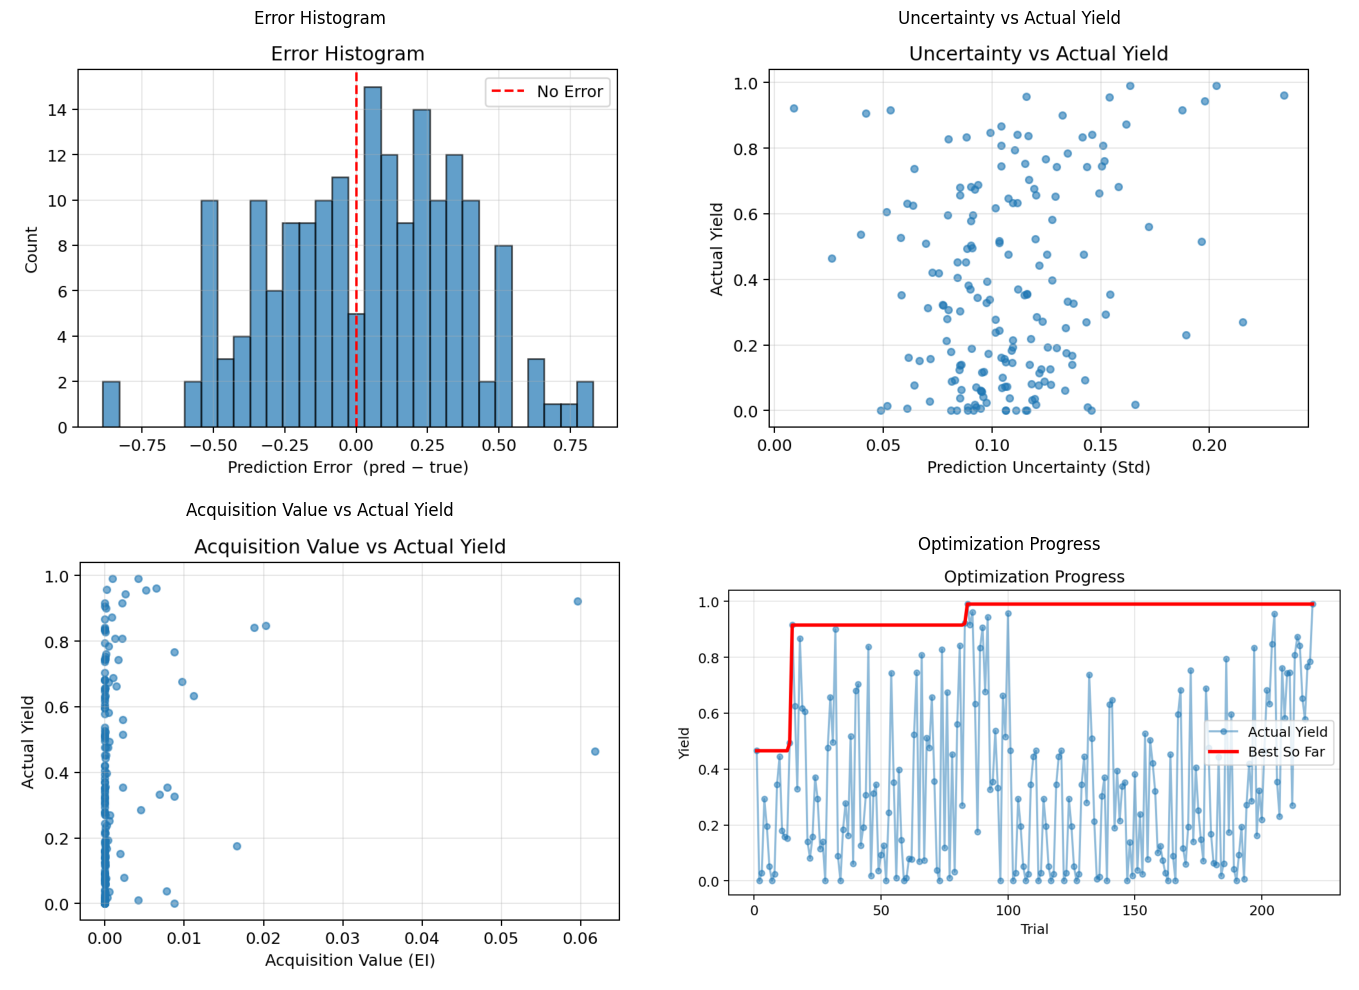

画像表示完了: ../runs/gnn_mcdropout_100trials_BH/visualization


In [ ]:
result = visualize_and_display_logs('../runs/gnn_bo_100trials_BH/optimization_log.csv')